In [1]:
from data import ImagePairDataset
from matplotlib import pyplot as plt
import torch

In [2]:
# Insecure - only run if you trust best_model.pt
model = torch.load('best_model.pt', weights_only=False)
model = model.to(torch.device('cpu'))

In [3]:
data = ImagePairDataset(split='test')

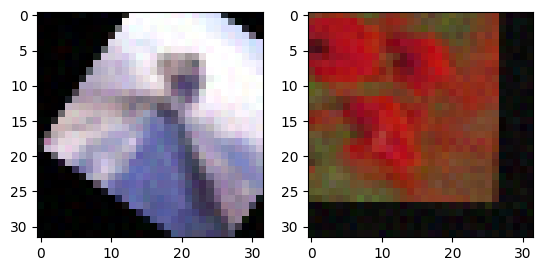

Model predicts different with 100.0% confidence. Model prediction is correct.





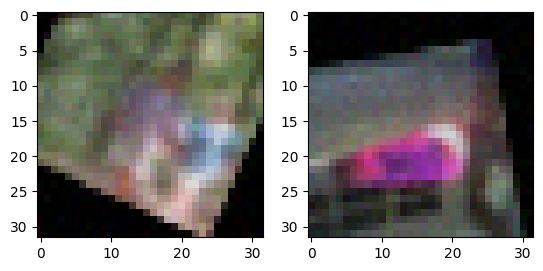

Model predicts different with 97.65% confidence. Model prediction is correct.





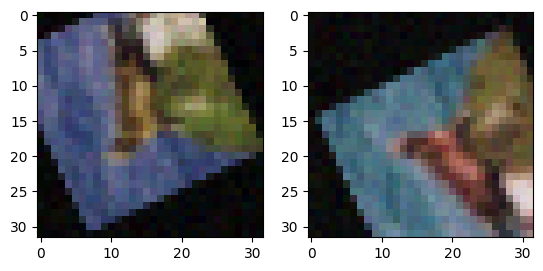

Model predicts same with 99.88% confidence. Model prediction is correct.





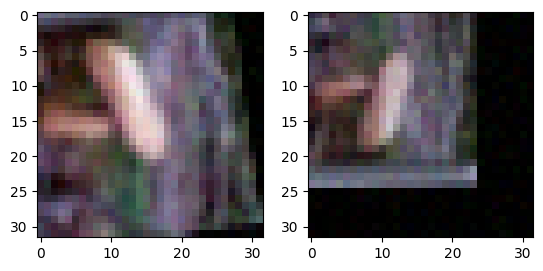

Model predicts same with 99.96% confidence. Model prediction is correct.





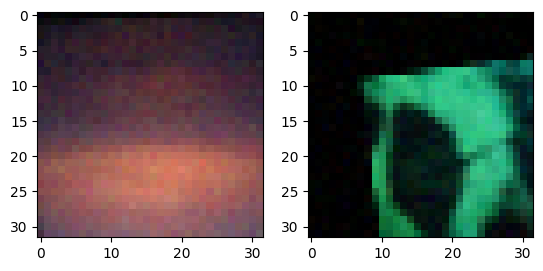

Model predicts different with 100.0% confidence. Model prediction is correct.





In [4]:
for i in range(5):
    
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(data[i][0].permute((1, 2, 0)))
    ax[1].imshow(data[i][1].permute((1, 2, 0)))
    plt.show()
    
    out = torch.sigmoid(model(data[i][0].unsqueeze(0), data[i][1].unsqueeze(0))).item()
    pred = 1.0 if out >= 0.5 else 0.0
    
    confidence = round(100 * max(out, 1 - out), 2)
    print(f"Model predicts {'same' if pred == 1.0 else 'different'} with {confidence}% confidence. Model prediction is {'correct' if pred == data[i][2] else 'incorrect.'}.\n\n\n")